## Example 1: univariate regression 

We start by considering univariate regression models. Here the goal is to predict a single
scalar output $y \in \mathbb{R}$ from input $x \in \mathbb{R}^D$ using a model $f[x,\boldsymbol\phi]$ with parameters $\boldsymbol\phi$. Following
the recipe, we choose a probability distribution over the output domain y. We select the
univariate normal distribution (figure 5.3), which is defined over $y \in \mathbb{R}$. 


<img src="assets/Chap05/LossNorm.svg" style="filter: invert(1);" align="right" width="40%">

The univariate normal distribution
(also known as the Gaussian distribution)
is defined on the real line $z \in \mathbb{R}$ and has parameters $\mu$ and $\sigma^2$. The
mean $\mu$ determines the position of the
peak. The positive root of the variance
$\sigma^2$ (the standard deviation) determines
the width of the distribution.
Since the total probability density sums
to one, the peak becomes higher as the
variance decreases and the distribution
becomes narrower.



This has two
parameters (mean $\mu$ and variance $\sigma^2$) and has a probability density function:

\begin{eqnarray}
  Pr(y|\mu,\sigma^2) = \frac{1}{\sqrt{2\pi\sigma^{2}}}\exp\left[-\frac{(y-\mu)^{2}}{2\sigma^{2}}\right].
 \end{eqnarray}

 Second, we set the machine learning model $f[x,\boldsymbol\phi]$ to compute one or more of the param-
eters of this distribution. Here, we just compute the mean so $\mu= f[x,\boldsymbol\phi]$:

\begin{eqnarray}\label{eq:loss_pdf_uni_reg}
  Pr(y|\mbox{f}[\mathbf{x},\boldsymbol\phi],\sigma^2) = \frac{1}{\sqrt{2\pi\sigma^{2}}}\exp\left[-\frac{(y-\mbox{f}[\mathbf{x},\boldsymbol\phi])^{2}}{2\sigma^{2}}\right].
 \end{eqnarray}

We aim to find the parameters $\boldsymbol\phi$ that make the training data ${x_i,y_i}$ most probable
under this distribution (figure 5.4). To accomplish this, we choose a loss function $L[\boldsymbol\phi]$
based on the negative log-likelihood:

\begin{eqnarray}\label{eq:loss_normal_full}
 L[\boldsymbol\phi] &=& -\sum_{i=1}^{I} \log\left[Pr(y_{i}|\mbox{f}[\mathbf{x}_{i},\boldsymbol\phi],\sigma^{2})\right]\nonumber \\
 &=&-\sum_{i=1}^{I} \log\left[\frac{1}{\sqrt{2\pi\sigma^{2}}}\exp\left[-\frac{(y_i-\mbox{f}[\mathbf{x}_i,\boldsymbol\phi])^{2}}{2\sigma^{2}}\right]\right].
 \end{eqnarray}

When we train the model, we seek parameters $\hat{\boldsymbol\phi}$ that minimize this loss.

### Least squares loss function 

Now let’s perform some algebraic manipulations on the loss function. We seek:

\begin{eqnarray}\label{eq:loss_normal_full2}
 \hat{\boldsymbol\phi} &=& \mathop{\rm argmin}_{\boldsymbol\phi}\left[-\sum_{i=1}^{I} \log\left[\frac{1}{\sqrt{2\pi\sigma^{2}}}\exp\left[-\frac{(y_i-\mbox{f}[\mathbf{x}_i,\boldsymbol\phi])^{2}}{2\sigma^{2}}\right]\right]\right]
 \nonumber \\
 &=&\mathop{\rm argmin}_{\boldsymbol\phi}\left[-\sum_{i=1}^{I} \left(\log\left[\frac{1}{\sqrt{2\pi\sigma^{2}}}\right] -\frac{(y_i-\mbox{f}[\mathbf{x}_i,\boldsymbol\phi])^{2}}{2\sigma^{2}}\right)\right]\nonumber \\
 &=& \mathop{\rm argmin}_{\boldsymbol\phi}\left[-\sum_{i=1}^{I} -\frac{(y_i-\mbox{f}[\mathbf{x}_i,\boldsymbol\phi])^{2}}{2\sigma^{2}}\right]\nonumber \\
 &=& \mathop{\rm argmin}_{\boldsymbol\phi}\left[\sum_{i=1}^{I} (y_i-\mbox{f}[\mathbf{x}_i,\boldsymbol\phi])^{2}\right],
 \end{eqnarray}

where we removed the first term between the second and third lines because it doesn’t
depend on $\boldsymbol\phi$. We removed the denominator between the third and fourth lines, as this is
just a constant positive scaling factor that does not affect the position of the minimum.
The result of these manipulations is the least squares loss function that we originally
introduced when we discussed linear regression in chapter 2:

\begin{eqnarray}\label{eq:loss_least_squares}
  L[\boldsymbol\phi] = \sum_{i=1}^{I} \bigl(y_i-\mbox{f}[\mathbf{x}_i,\boldsymbol\phi]\bigr)^{2}.
 \end{eqnarray}

We see that the least squares loss function follows naturally from the assumptions that the
predictions are (i) independent and (ii) drawn from a normal distribution with mean $\mu=
\mbox{f}[\mathbf{x}_i,\boldsymbol\phi]$ (figure 5.4).

<img src="assets/Chap05/LossNormalRegression.svg" style="filter: invert(1);" width="100%">

Equivalence of least squares and maximum likelihood loss for the
normal distribution. a) Consider the linear model from figure 2.2. The least
squares criterion minimizes the sum of the squares of the deviations (dashed lines)
between the model prediction f[xi,ϕ] (green line) and the true output values yi
(orange points). Here the fit is good, so these deviations are small (e.g., for the
two highlighted points). b) For these parameters, the fit is bad, and the squared
deviations are large. c) The least squares criterion follows from the assumption
that the model predicts the mean of a normal distribution over the outputs and
that we maximize the probability. For the first case, the model fits well, so the
probability Pr(yi|xi) of the data (horizontal orange dashed lines) is large (and
the negative log probability is small). d) For the second case, the model fits badly,
so the probability is small and the negative log probability is large.

### Inference 

The network no longer directly predicts y but instead predicts the mean $\mu = \mbox{f}[\mathbf{x},\boldsymbol\phi]$ of
the normal distribution over y. When we perform inference, we usually want a single
“best” point estimate $\hat{y}$, so we take the maximum of the predicted distribution:

\begin{eqnarray}
  \hat{y} = \mathop{\rm argmax}_{y}\left[Pr(y|\mbox{f}[\mathbf{x},\hat{\boldsymbol\phi}],\sigma^2)\right].
 \end{eqnarray}

For the univariate normal distribution, the maximum position is determined by the mean
parameter $\mu$ (figure 5.3). This is precisely what the model computed, so $\hat{y} = \mbox{f}[\mathbf{x},\hat{\boldsymbol\phi}]$.

### Estimating variance 

To formulate the least squares loss function, we assumed that the network predicted the
mean of a normal distribution. The final expression in equation 5.11 (perhaps surprisingly) does not depend on the variance $\sigma^2$. However, there is nothing to stop us from
treating $\sigma^2$ as a learned parameter and minimizing equation 5.9 with respect to both the
model parameters $\boldsymbol\phi$ and the distribution variance $\sigma^2$:

\begin{eqnarray}
 \hat{\boldsymbol\phi},\hat{\sigma}^{2} = \mathop{\rm argmin}_{\boldsymbol\phi,\sigma^{2}}\left[-\sum_{i=1}^{I} \log\left[\frac{1}{\sqrt{2\pi\sigma^{2}}}\exp\left[-\frac{(y_i-\mbox{f}[\mathbf{x}_i,\boldsymbol\phi])^{2}}{2\sigma^{2}}\right]\right]\right].
 \end{eqnarray}

In inference, the model predicts the mean µ= f[x,
ϕ] from the input, and we learned the
varianceˆ
σ2 during the training process. The former is the best prediction. The latter
tells us about the uncertainty of the prediction.


### Heteroscedastic regression

The model above assumes that the variance of the data is constant everywhere. However,
this might be unrealistic. When the uncertainty of the model varies as a function of the
input data, we refer to this as heteroscedastic (as opposed to homoscedastic, where the
uncertainty is constant).
A simple way to model this is to train a neural network f[x,ϕ] that computes both
the mean and the variance. For example, consider a shallow network with two outputs.
We denote the first output as f1[x,ϕ] and use this to predict the mean, and we denote
the second output as f2[x,ϕ] and use it to predict the variance.
There is one complication; the variance must be positive, but we can’t guarantee
that the network will always produce a positive output. To ensure that the computed
variance is positive, we pass the second network output through a function that maps
an arbitrary value to a positive one. A suitable choice is the squaring function, giving:

\begin{eqnarray}
 \mu &=& \mbox{f}_1[\mathbf{x},\boldsymbol\phi] \nonumber \\
 \sigma^2 &=& \mbox{f}_2[\mathbf{x},\boldsymbol\phi]^2,
 \end{eqnarray}

which results in the loss function:

\begin{eqnarray}
 \hat{\boldsymbol\phi} = \mathop{\rm argmin}_{\boldsymbol\phi}\left[-\sum_{i=1}^{I} \biggl(\log\left[\frac{1}{\sqrt{2\pi\mbox{f}_2[\mathbf{x}_i,\boldsymbol\phi]^2}}\right] -\frac{(y_i-\mbox{f}_1[\mathbf{x}_i,\boldsymbol\phi])^{2}}{2\mbox{f}_2[\mathbf{x}_i,\boldsymbol\phi]^2}\biggr)\right].
 \end{eqnarray}

<img src="assets/Chap05/LossHeteroscedastic.svg" style="filter: invert(1);" width="100%">

Homoscedastic vs. heteroscedastic regression. a) A shallow neural
network for homoscedastic regression predicts just the mean μ of the output
distribution from the input x. b) The result is that while the mean (blue line)
is a piecewise linear function of the input x, the variance is constant everywhere
(arrows and gray region show ±2 standard deviations). c) A shallow neural
network for heteroscedastic regression also predicts the variance σ2 (or, more
precisely, computes its square root, which we then square). d) The standard
deviation now also becomes a piecewise linear function of the input x.




<!-- \begin{eqnarray}
  Pr(y|\lambda,\mu_1,\mu_2,\sigma^2_1,\sigma^2_2) = \frac{\lambda}{\sqrt{2\pi\sigma_1^{2}}}\exp\left[\frac{-(y-\mu_1)^{2}}{2\sigma_1^{2}}\right]+\frac{1-\lambda}{\sqrt{2\pi\sigma_2^{2}}}\exp\left[\frac{-(y-\mu_2)^{2}}{2\sigma_2^{2}}\right],
 \end{eqnarray}

\begin{eqnarray}
  Pr(y=k)=\frac{\lambda^{k}e^{-\lambda}}{k!}. 
 \end{eqnarray} -->


In [13]:
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt
# Import math Library
import math

plt.style.use('dark_background');
     

# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

# Define a shallow neural network
def shallow_nn(x, beta_0, omega_0, beta_1, omega_1):
    # Make sure that input data is (1 x n_data) array
    n_data = x.size
    x = np.reshape(x,(1,n_data))

    # This runs the network for ALL of the inputs, x at once so we can draw graph
    h1 = ReLU(np.matmul(beta_0,np.ones((1,n_data))) + np.matmul(omega_0,x))
    y = np.matmul(beta_1,np.ones((1,n_data))) + np.matmul(omega_1,h1)
    return y
     

# Get parameters for model -- we can call this function to easily reset them
def get_parameters():
  # And we'll create a network that approximately fits it
  beta_0 = np.zeros((3,1));  # formerly theta_x0
  omega_0 = np.zeros((3,1)); # formerly theta_x1
  beta_1 = np.zeros((1,1));  # formerly phi_0
  omega_1 = np.zeros((1,3)); # formerly phi_x

  beta_0[0,0] = 0.3; beta_0[1,0] = -1.0; beta_0[2,0] = -0.5
  omega_0[0,0] = -1.0; omega_0[1,0] = 1.8; omega_0[2,0] = 0.65
  beta_1[0,0] = 0.1;
  omega_1[0,0] = -2.0; omega_1[0,1] = -1.0; omega_1[0,2] = 7.0

  return beta_0, omega_0, beta_1, omega_1
     

# Utility function for plotting data
def plot_univariate_regression(x_model, y_model, x_data = None, y_data = None, sigma_model = None, title= None):
  # Make sure model data are 1D arrays
  x_model = np.squeeze(x_model)
  y_model = np.squeeze(y_model)

  fig, ax = plt.subplots()
  ax.plot(x_model,y_model)
  if sigma_model is not None:
    ax.fill_between(x_model, y_model-2*sigma_model, y_model+2*sigma_model, color='lightgray')
  ax.set_xlabel(r'Input, $x$'); ax.set_ylabel(r'Output, $y$')
  ax.set_xlim([0,1]);ax.set_ylim([-1,1])
  ax.set_aspect(0.5)
  if title is not None:
    ax.set_title(title)
  if x_data is not None:
    ax.plot(x_data, y_data, 'ko')
  plt.show()

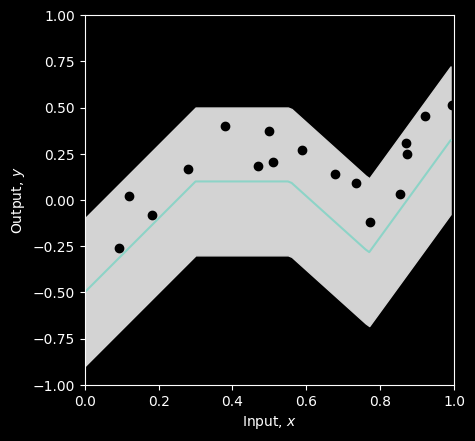

In [14]:
# Let's create some 1D training data
x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([-0.25934537,0.18195445,0.651270150,0.13921448,0.09366691,0.30567674,\
                    0.372291170,0.20716968,-0.08131792,0.51187806,0.16943738,0.3994327,\
                    0.019062570,0.55820410,0.452564960,-0.1183121,0.02957665,-1.24354444, \
                    0.248038840,0.26824970])

# Get parameters for the model
beta_0, omega_0, beta_1, omega_1 = get_parameters()
sigma = 0.2

# Define a range of input values
x_model = np.arange(0,1,0.01)
# Run the model to get values to plot and plot it.
y_model = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
plot_univariate_regression(x_model, y_model, x_train, y_train, sigma_model = sigma)

The blue line is the mean prediction of the model and the gray area represents plus/minus two standard deviations. This model fits okay, but could be improved. Let's compute the loss. We'll compute the the least squares error, the likelihood, the negative log likelihood.

Correct answer = 0.119, Your answer = 0.119


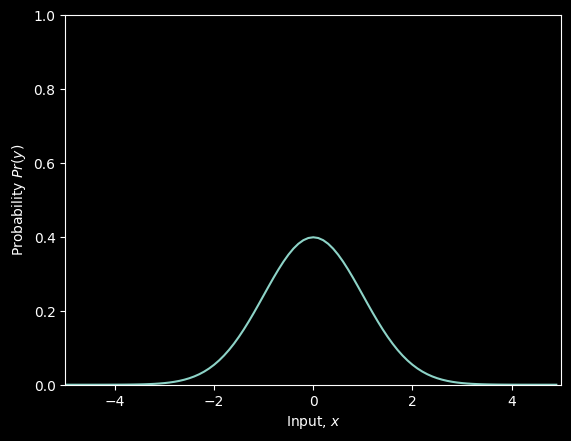

In [36]:
# Return probability under normal distribution
def normal_distribution(y, mu, sigma):
    #the equation for the normal distribution
    prob = np.exp(-((y - mu)**2) / (2.0 * sigma**2.0)) / (sigma * np.sqrt(2.0 * np.pi))

    return prob
     

# Let's double check we get the right answer before proceeding
print("Correct answer = %3.3f, Your answer = %3.3f"%(0.119,normal_distribution(1,-1,2.3)))
     

# Let's plot the Gaussian distribution.
y_gauss = np.arange(-5,5,0.1)
mu = 0; sigma = 1.0
gauss_prob = normal_distribution(y_gauss, mu, sigma)
fig, ax = plt.subplots()
ax.plot(y_gauss, gauss_prob)
ax.set_xlabel(r'Input, $x$'); ax.set_ylabel(r'Probability $Pr(y)$')
ax.set_xlim([-5,5]);ax.set_ylim([0,1.0])
plt.show()

Now let's compute the likelihood using this function

In [39]:
# Return the likelihood of all of the data under the model
def compute_likelihood(y_train, mu, sigma):
  # TODO -- compute the likelihood of the data -- the product of the normal probabilities for each data point
  # Top line of equation 5.3 in the notes
  # You will need np.prod() and the normal_distribution function you used above
  # Replace the line below
  # likelihood = #

  likelihood = np.prod(normal_distribution(y_train, mu, sigma))

  return likelihood
     

# Let's test this for a homoscedastic (constant sigma) model
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Use our neural network to predict the mean of the Gaussian
mu_pred = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
# Set the standard deviation to something reasonable
sigma = 0.2
# Compute the likelihood
likelihood = compute_likelihood(y_train, mu_pred, sigma)
# Let's double check we get the right answer before proceeding
print("Correct answer = %9.9f, Your answer = %9.9f"%(0.000010624,likelihood))

Correct answer = 0.000010624, Your answer = 0.000010624


You can see that this gives a very small answer, even for this small 1D dataset, and with the model fitting quite well. This is because it is the product of several probabilities, which are all quite small themselves. This will get out of hand pretty quickly with real datasets -- the likelihood will get so small that we can't represent it with normal finite-precision math

This is why we use negative log likelihood

In [ ]:
# Return the negative log likelihood of the data under the model
def compute_negative_log_likelihood(y_train, mu, sigma):
  # negative log likelihood of the data without using a product
  
  nll = -1 * np.sum(np.log(normal_distribution(y_train, mu, sigma)))

  return nll
     

# Let's test this for a homoscedastic (constant sigma) model
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Use our neural network to predict the mean of the Gaussian
mu_pred = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
# Set the standard deviation to something reasonable
sigma = 0.2
# Compute the negative log likelihood
nll = compute_negative_log_likelihood(y_train, mu_pred, sigma)
# Let's double check we get the right answer before proceeding
print("Correct answer = %9.9f, Your answer = %9.9f"%(11.452419564,nll))

Correct answer = 11.452419564, Your answer = 11.452419564


For good measure, let's compute the sum of squares as well

In [40]:
# Return the squared distance between the observed data (y_train) and the prediction of the model (y_pred)
def compute_sum_of_squares(y_train, y_pred):
  # TODO -- compute the sum of squared distances between the training data and the model prediction
  # Eqn 5.10 in the notes.  Make sure that you understand this, and ask questions if you don't
  # Replace the line below
  sum_of_squares = np.sum((y_train - y_pred)**2)

  return sum_of_squares
     

# Let's test this again
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Use our neural network to predict the mean of the Gaussian, which is out best prediction of y
y_pred = mu_pred = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
# Compute the sum of squares
sum_of_squares = compute_sum_of_squares(y_train, y_pred)
# Let's double check we get the right answer before proceeding
print("Correct answer = %9.9f, Your answer = %9.9f"%(2.020992572,sum_of_squares))

Correct answer = 2.020992572, Your answer = 2.020992572


Now let's investigate finding the maximum likelihood / minimum negative log likelihood / least squares solution. For simplicity, we'll assume that all the parameters are correct except one and look at how the likelihood, negative log likelihood, and sum of squares change as we manipulate the last parameter. We'll start with overall y offset, beta_1 (formerly phi_0)

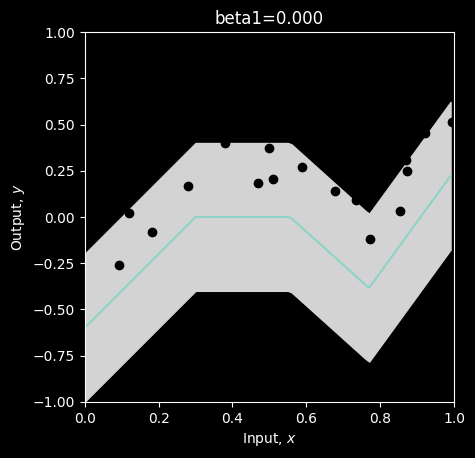

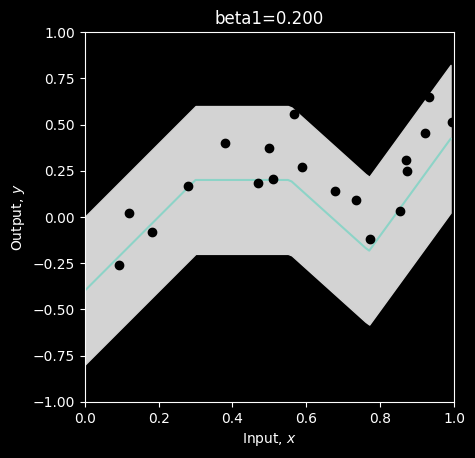

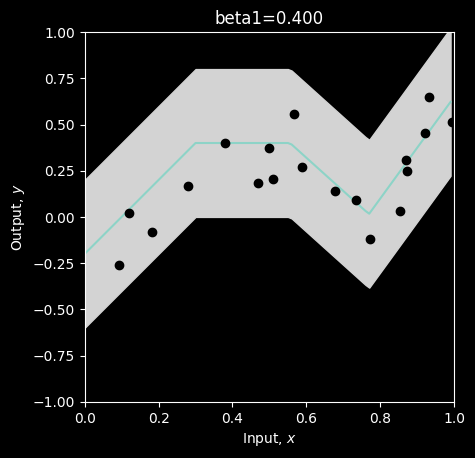

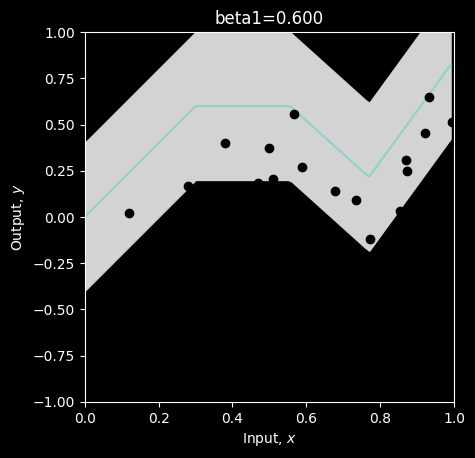

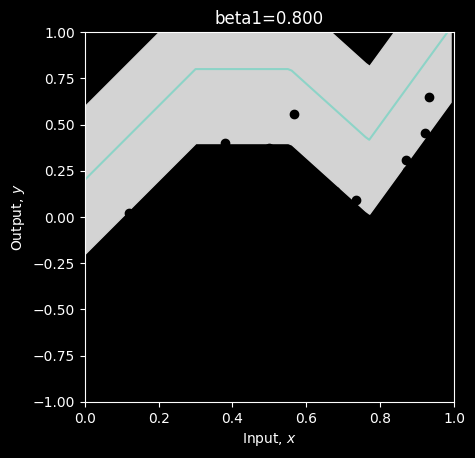

In [19]:
# Define a range of values for the parameter
beta_1_vals = np.arange(0,1.0,0.01)
# Create some arrays to store the likelihoods, negative log likelihoods and sum of squares
likelihoods = np.zeros_like(beta_1_vals)
nlls = np.zeros_like(beta_1_vals)
sum_squares = np.zeros_like(beta_1_vals)

# Initialise the parameters
beta_0, omega_0, beta_1, omega_1 = get_parameters()
sigma = 0.2
for count in range(len(beta_1_vals)):
  # Set the value for the parameter
  beta_1[0,0] = beta_1_vals[count]
  # Run the network with new parameters
  mu_pred = y_pred = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
  # Compute and store the three values
  likelihoods[count] = compute_likelihood(y_train, mu_pred, sigma)
  nlls[count] = compute_negative_log_likelihood(y_train, mu_pred, sigma)
  sum_squares[count] = compute_sum_of_squares(y_train, y_pred)
  # Draw the model for every 20th parameter setting
  if count % 20 == 0:
    # Run the model to get values to plot and plot it.
    y_model = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
    plot_univariate_regression(x_model, y_model, x_train, y_train, sigma_model = sigma, title="beta1=%3.3f"%(beta_1[0,0]))

ValueError: x and y must have same first dimension, but have shapes (100,) and (80,)

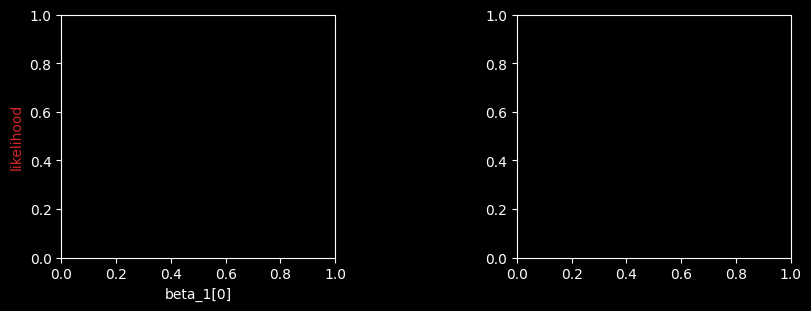

In [41]:
# Now let's plot the likelihood, negative log likelihood, and least squares as a function of the value of the offset beta1
fig, ax = plt.subplots(1,2)
fig.set_size_inches(10.5, 5.5)
fig.tight_layout(pad=10.0)
likelihood_color = 'tab:red'
nll_color = 'tab:blue'

ax[0].set_xlabel('beta_1[0]')
ax[0].set_ylabel('likelihood', color = likelihood_color)
ax[0].plot(beta_1_vals, likelihoods, color = likelihood_color)
ax[0].tick_params(axis='y', labelcolor=likelihood_color)

ax00 = ax[0].twinx()
ax00.plot(beta_1_vals, nlls, color = nll_color)
ax00.set_ylabel('negative log likelihood', color = nll_color)
ax00.tick_params(axis='y', labelcolor = nll_color)

plt.axvline(x = beta_1_vals[np.argmax(likelihoods)], linestyle='dotted')

ax[1].plot(beta_1_vals, sum_squares); ax[1].set_xlabel('beta_1[0]'); ax[1].set_ylabel('sum of squares')
plt.show()

Maximum likelihood = 0.000, at beta_1=0.000
Minimum negative log likelihood = 0.000, at beta_1=0.000
Least squares = 0.000, at beta_1=0.000


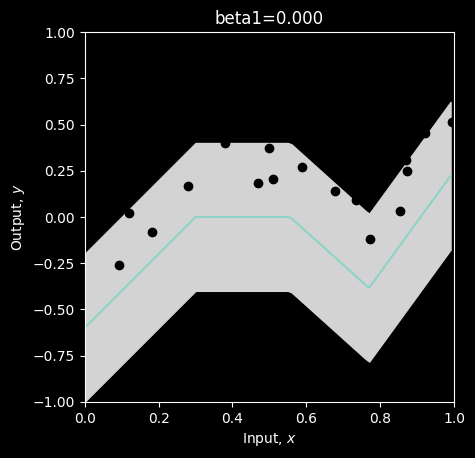

In [42]:
# Hopefully, you can see that the maximum of the likelihood fn is at the same position as the minimum negative log likelihood
# and the least squares solutions
# Let's check that:
print("Maximum likelihood = %3.3f, at beta_1=%3.3f"%( (likelihoods[np.argmax(likelihoods)],beta_1_vals[np.argmax(likelihoods)])))
print("Minimum negative log likelihood = %3.3f, at beta_1=%3.3f"%( (nlls[np.argmin(nlls)],beta_1_vals[np.argmin(nlls)])))
print("Least squares = %3.3f, at beta_1=%3.3f"%( (sum_squares[np.argmin(sum_squares)],beta_1_vals[np.argmin(sum_squares)])))

# Plot the best model
beta_1[0,0] = beta_1_vals[np.argmin(sum_squares)]
y_model = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
plot_univariate_regression(x_model, y_model, x_train, y_train, sigma_model = sigma, title="beta1=%3.3f"%(beta_1[0,0]))

They all give the same answer. But you can see from the three plots above that the likelihood is very small unless the parameters are almost correct. So in practice, we would work with the negative log likelihood or the least squares.

Let's do the same thing with the standard deviation parameter of our network. This is not an output of the network (unless we choose to make that the case), but it still affects the likelihood.

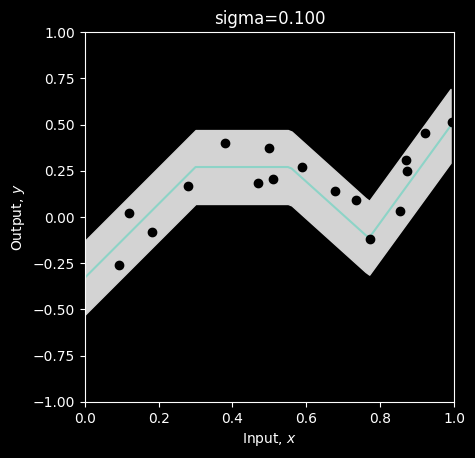

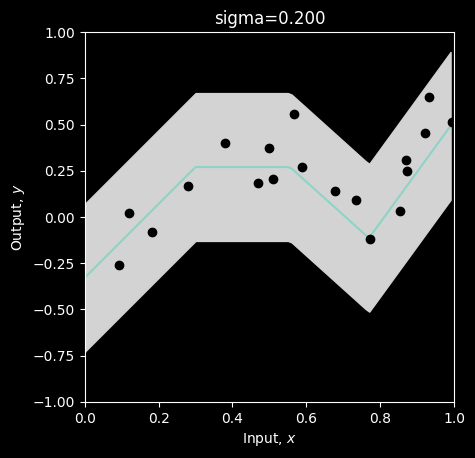

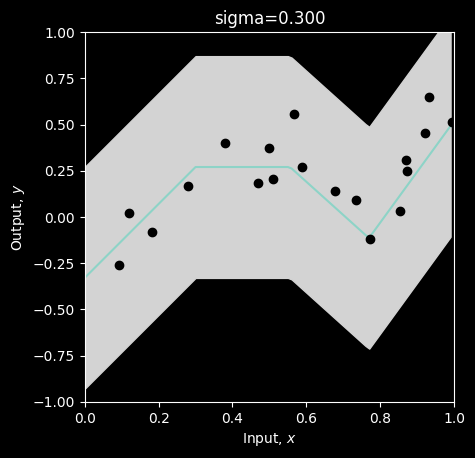

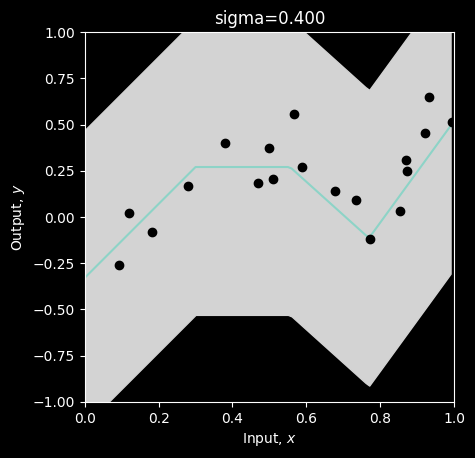

In [22]:
# Define a range of values for the parameter
sigma_vals = np.arange(0.1,0.5,0.005)
# Create some arrays to store the likelihoods, negative log likelihoods and sum of squares
likelihoods = np.zeros_like(sigma_vals)
nlls = np.zeros_like(sigma_vals)
sum_squares = np.zeros_like(sigma_vals)

# Initialise the parameters
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Might as well set to the best offset
beta_1[0,0] = 0.27
for count in range(len(sigma_vals)):
  # Set the value for the parameter
  sigma = sigma_vals[count]
  # Run the network with new parameters
  mu_pred = y_pred = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
  # Compute and store the three values
  likelihoods[count] = compute_likelihood(y_train, mu_pred, sigma)
  nlls[count] = compute_negative_log_likelihood(y_train, mu_pred, sigma)
  sum_squares[count] = compute_sum_of_squares(y_train, y_pred)
  # Draw the model for every 20th parameter setting
  if count % 20 == 0:
    # Run the model to get values to plot and plot it.
    y_model = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
    plot_univariate_regression(x_model, y_model, x_train, y_train, sigma_model=sigma, title="sigma=%3.3f"%(sigma))

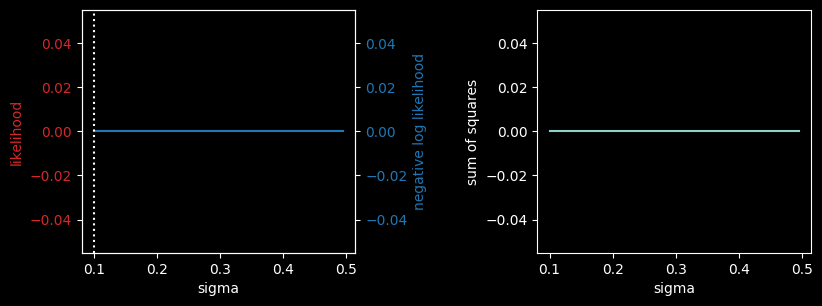

In [23]:
# Now let's plot the likelihood, negative log likelihood, and least squares as a function of the value of the standard deviation sigma
fig, ax = plt.subplots(1,2)
fig.set_size_inches(10.5, 5.5)
fig.tight_layout(pad=10.0)
likelihood_color = 'tab:red'
nll_color = 'tab:blue'


ax[0].set_xlabel('sigma')
ax[0].set_ylabel('likelihood', color = likelihood_color)
ax[0].plot(sigma_vals, likelihoods, color = likelihood_color)
ax[0].tick_params(axis='y', labelcolor=likelihood_color)

ax00 = ax[0].twinx()
ax00.plot(sigma_vals, nlls, color = nll_color)
ax00.set_ylabel('negative log likelihood', color = nll_color)
ax00.tick_params(axis='y', labelcolor = nll_color)

plt.axvline(x = sigma_vals[np.argmax(likelihoods)], linestyle='dotted')

ax[1].plot(sigma_vals, sum_squares); ax[1].set_xlabel('sigma'); ax[1].set_ylabel('sum of squares')
plt.show()

Maximum likelihood = 0.000, at sigma=0.100
Minimum negative log likelihood = 0.000, at sigma=0.100


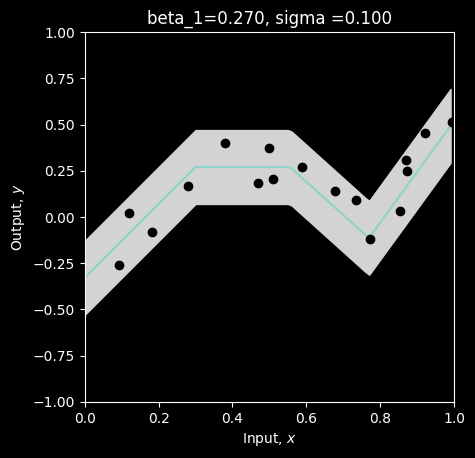

In [24]:
# Hopefully, you can see that the maximum of the likelihood fn is at the same position as the minimum negative log likelihood
# The least squares solution does not depend on sigma, so it's just flat -- no use here.
# Let's check that:
print("Maximum likelihood = %3.3f, at sigma=%3.3f"%( (likelihoods[np.argmax(likelihoods)],sigma_vals[np.argmax(likelihoods)])))
print("Minimum negative log likelihood = %3.3f, at sigma=%3.3f"%( (nlls[np.argmin(nlls)],sigma_vals[np.argmin(nlls)])))
# Plot the best model
sigma= sigma_vals[np.argmin(nlls)]
y_model = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
plot_univariate_regression(x_model, y_model, x_train, y_train, sigma_model = sigma, title="beta_1=%3.3f, sigma =%3.3f"%(beta_1[0,0],sigma))

Obviously, to fit the full neural model we would vary all of the 10 parameters of the network in $\mathbf{\beta_0, \omega_0, \beta_1, \omega_1}$
 (and maybe $\sigma$) until we find the combination that have the maximum likelihood / minimum negative log likelihood / least squares.


Here we just varied one at a time as it is easier to see what is going on. This is known as coordinate descent.